# Appliance Energy Prediction - Pipeline Runner

End-to-end pipeline execution in sequence:

| Step | Module | Description |
|------|--------|-------------|
| 1 | `data_preprocessing.py` | Load, clean, outlier treatment, temporal split |
| 2 | `feature_engineering.py` | Lag, rolling, cyclical, interaction features + scaling |
| 3 | `train.py` | Ridge Regression & Random Forest with hyperparameter tuning |
| 4 | `model.py` | DL architecture review (LSTM, GRU, CNN-LSTM) |
| 5 | `train_dl.py` | Train & evaluate all DL models |
| 6 | - | Final comparison across all models |

## Setup

In [ ]:
import sys
import os
import importlib
import numpy as np
import pandas as pd

# Add src/ to path for imports
_cwd  = os.getcwd()
ROOT  = _cwd if os.path.isdir(os.path.join(_cwd, 'src')) else os.path.abspath(os.path.join(_cwd, '..'))
SRC   = os.path.join(ROOT, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(f"Project root : {ROOT}")
print(f"src path     : {SRC}")

Project root : d:\My_Intern_Project
src path     : d:\My_Intern_Project\src


---
## Step 1 - Data Preprocessing
Loads the raw CSV, drops noise columns, handles missing values, caps outliers (IQR Winsorization), adds time features, and splits 80/20 temporally.

In [28]:
import data_preprocessing
importlib.reload(data_preprocessing)

train_df, test_df = data_preprocessing.run()

STEP 1 — Data Preprocessing
[load]    shape=(19735, 27)  |  2016-01-11 → 2016-05-27
[missing] missing cells before: 0
[missing] missing cells after : 0
[outlier] IQR bounds : [-25.0, 175.0] Wh
[outlier] IQR outliers   : 2138  (10.8%)
[outlier] Z-score outliers (|z|>3): 540  (2.7%)
[outlier] capped at 175.0 Wh  |  new max=175.0 Wh
[features] added: hour, NSM
[split]   train: 15788 rows  (2016-01-11 → 2016-04-30)
[split]   test : 3947 rows  (2016-04-30 → 2016-05-27)
[save]    train → d:\My_Intern_Project\data\processed\train.csv
[save]    test  → d:\My_Intern_Project\data\processed\test.csv
Preprocessing complete.


---
## Step 2 - Feature Engineering
Adds cyclical encodings, lag features, rolling statistics, and interaction terms — applied independently to each split. Fits MinMaxScaler on train only.

In [29]:
import feature_engineering
importlib.reload(feature_engineering)

train_eng, test_eng, feat_scaler, feature_cols = feature_engineering.run()

STEP 2 — Feature Engineering
[load]  train: (15788, 29)  |  test: (3947, 29)
[engineer:train]  15788 → 15644 rows  (dropped 144 NaN rows from lags)
[engineer:test]  3947 → 3803 rows  (dropped 144 NaN rows from lags)

[scale]  Feature groups:
         [A] Cyclical      ( 4) : ['hour_sin', 'hour_cos', 'NSM_sin', 'NSM_cos']
         [B] Lag           ( 4) : ['lag_1', 'lag_3', 'lag_6', 'lag_144']
         [C] Rolling       ( 4) : ['roll_mean_6', 'roll_std_6', 'roll_mean_18', 'roll_std_18']
         [D] Interaction   ( 2) : ['T_out_x_RH_out', 'T1_x_RH_1']
         [original sensor] (25) : 25 columns
         Total features    : 39

[save]  train_engineered.csv  →  (15644, 41)
[save]  test_engineered.csv   →  (3803, 41)
[save]  minmax_scaler.pkl     →  models/
Feature engineering complete.


---
## Step 3 - Baseline Model Training
Trains Ridge Regression (GridSearchCV, 5-fold TimeSeriesSplit) and Random Forest (RandomizedSearchCV, 20 iterations). Evaluates on the temporal test set.

STEP 3 — Baseline Model Training
[load]  X_train: (15644, 39)  |  X_test: (3803, 39)

[LR]  GridSearchCV over alpha (TimeSeriesSplit, 5 folds)...
[LR]  Best params : {'alpha': 10.0}
[LR]  Best CV RMSE: 22.8482

[RF]  RandomizedSearchCV (20 iterations, TimeSeriesSplit 3 folds)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[RF]  Best params : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
[RF]  Best CV RMSE: 23.6337

Evaluation on Test Set

[Linear Regression]
  MAE  : 13.4772
  RMSE : 21.1702
  MAPE : 17.41%
  R²   : 0.6989

[Random Forest]
  MAE  : 15.0692
  RMSE : 21.5346
  MAPE : 19.94%
  R²   : 0.6885

Performance Comparison
                       MAE     RMSE     MAPE      R2
Model                                               
Linear Regression  13.4772  21.1702  17.4107  0.6989
Random Forest      15.0692  21.5346  19.9426  0.6885


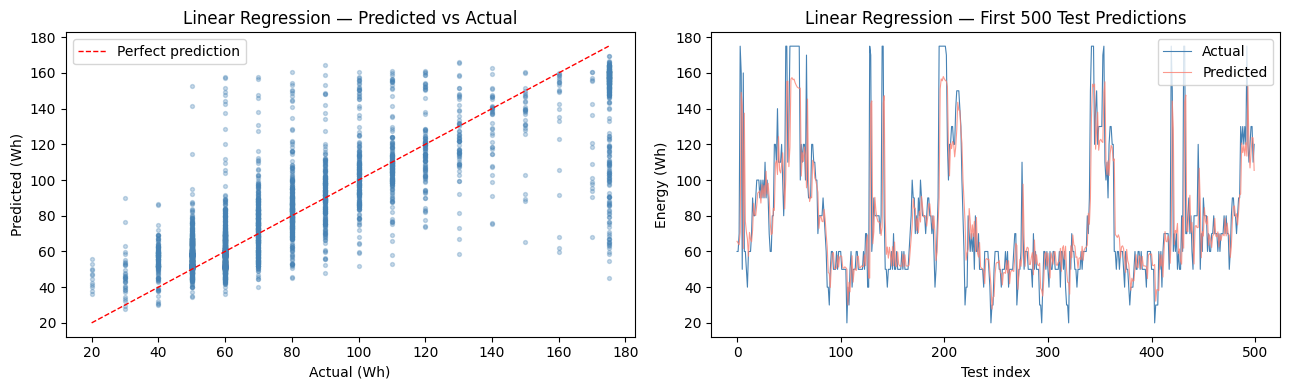

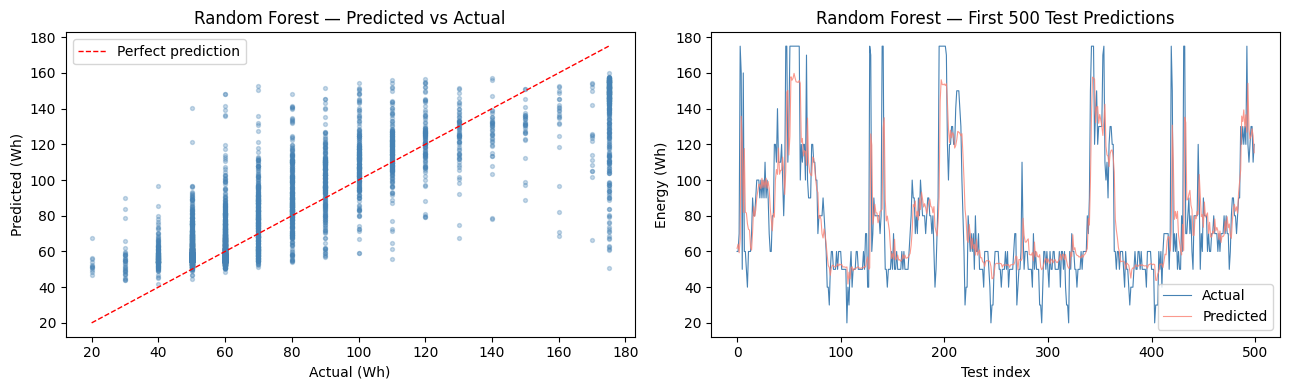

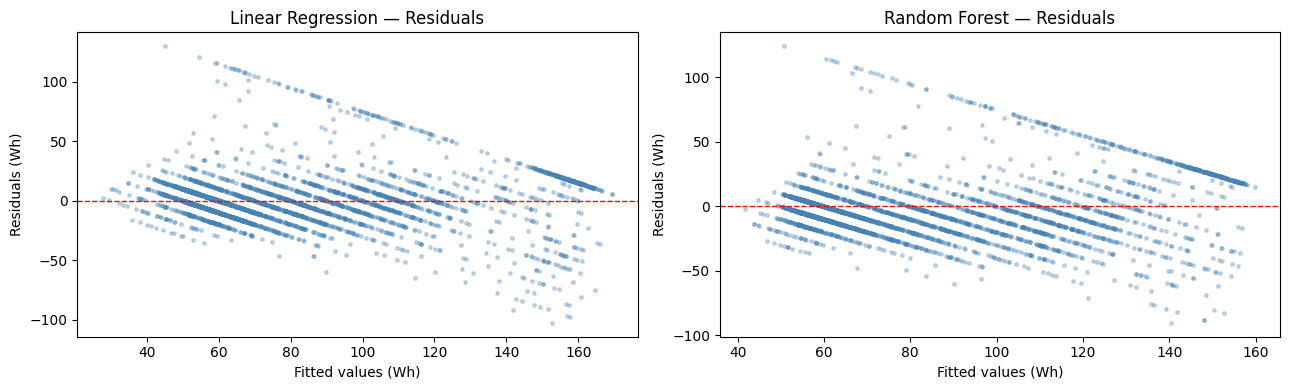

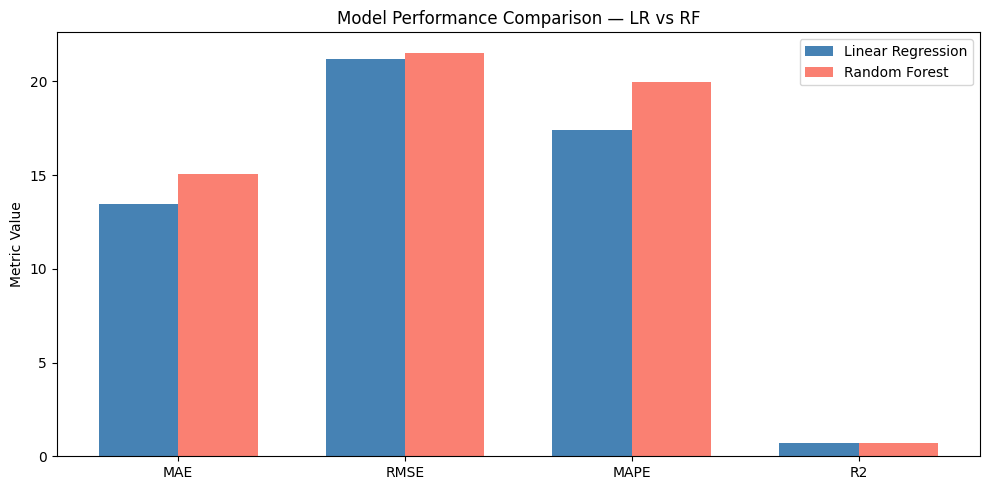

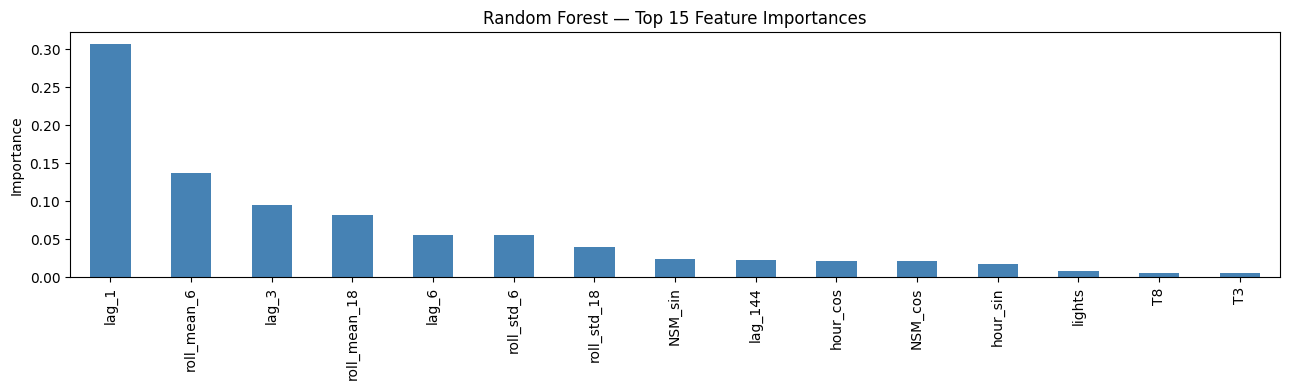


[save]  lr_model.h5  →  models/
[save]  rf_model.h5  →  models/

Baseline training complete.


In [ ]:
import train as train_module   
importlib.reload(train_module)

lr_model, rf_model, lr_metrics, rf_metrics = train_module.run()

---
## Step 4 - Deep Learning Model Architectures
Displays the layer structure and parameter counts for LSTM, GRU, and CNN-LSTM before training.

In [ ]:
import model as model_module   
importlib.reload(model_module)

_df         = pd.read_csv(os.path.join(ROOT, 'data', 'processed', 'train_engineered.csv'))
_X          = _df.drop(columns=['date', 'Appliances']).values
_X3d, _     = model_module.create_sequences(_X, _df['Appliances'].values, model_module.SEQ_LEN)
input_shape = (_X3d.shape[1], _X3d.shape[2])
print(f"Sequence input shape: (batch, {input_shape[0]} timesteps, {input_shape[1]} features)\n")

DL_CONFIGS = [
    ("LSTM",     model_module.build_lstm,     {"units": 128, "dropout": 0.2, "lr": 0.001}),
    ("GRU",      model_module.build_gru,      {"units": 64,  "dropout": 0.2, "lr": 0.001}),
    ("CNN-LSTM", model_module.build_cnn_lstm, {"filters": 64, "units": 64, "dropout": 0.2, "lr": 0.001}),
]

for arch_name, build_fn, params in DL_CONFIGS:
    print(f"\n{'='*55}")
    print(f"  {arch_name}")
    print(f"{'='*55}")
    build_fn(input_shape, **params).summary()

Sequence input shape: (batch, 24 timesteps, 39 features)


  LSTM


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 24, 128)        │        86,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,209 (555.50 KB)

 Trainable params: 141,953 (554.50 KB)

...

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 22, 64)         │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 11, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,105 (184.00 KB)

 Trainable params: 46,977 (183.50 KB)

 Non-trainable params: 128 (512.00 B)

In [32]:
param_rows = []
for arch_name, build_fn, params in DL_CONFIGS:
    mdl = build_fn(input_shape, **params)
    param_rows.append({
        "Model"           : arch_name,
        "Total Params"    : mdl.count_params(),
        "Trainable Params": sum(w.numpy().size for w in mdl.trainable_weights),
    })

pd.DataFrame(param_rows).set_index("Model")

,Total Params,Trainable Params
Model,,
LSTM,142209,141953
GRU,34049,33921
CNN-LSTM,47105,46977


---
## Step 5 - Deep Learning Training
Trains LSTM, GRU, and CNN-LSTM with fixed best hyperparameters. Uses EarlyStopping and ReduceLROnPlateau. Evaluates all models on the same test rows for a fair comparison.

In [ ]:
import train_dl
importlib.reload(train_dl)

import tensorflow as tf
tf.keras.backend.clear_session()  # resets layer name counters before training

lstm_model, gru_model, cnn_lstm_model, all_metrics = train_dl.run()

---
## Step 6 - All Models Comparison
Combines metrics from all five models into a single DataFrame.

In [ ]:
seen, deduped = set(), []
for entry in [lr_metrics, rf_metrics] + all_metrics:
    if entry["Model"] not in seen:
        deduped.append(entry)
        seen.add(entry["Model"])

results_df = pd.DataFrame(deduped).set_index("Model")
results_df = results_df[["MAE", "RMSE", "MAPE", "R2"]].round(4)
results_df

,MAE,RMSE,MAPE,R2
Model,,,,
Linear Regression,13.4772,21.1702,17.4107,0.6989
Random Forest,15.0692,21.5346,19.9426,0.6885
LSTM,14.1925,21.3707,18.4392,0.6934
GRU,13.6448,20.7569,17.9135,0.7108
CNN-LSTM,14.3618,21.3965,18.8435,0.6927
